## 本机关系约束后训练：冻结对照与独立验证

本节来自真实执行的 Qwen2.5-0.5B 本机试验。5 个版本 × 3 个种子；详细报告见 `runs/local_scheme_validation/20260923_relational_v2/REPORT.md`。

**本轮没有通过冻结的效果门槛，不能确认方案已有效提升。**

训练数据的编号可透露标签顺序，但本轮只将 prompt 送入模型；详见独立审查。此实验不等同于真实自然语言的因果推断。

In [1]:
from pathlib import Path
import json, hashlib
root = Path.cwd()
while not (root / 'runs/local_scheme_validation').exists() and root.parent != root:
    root = root.parent
run = root / 'runs/local_scheme_validation/20260923_relational_v2'
summary = json.loads((run / 'summary.json').read_text(encoding='utf-8'))
verification = json.loads((run / 'verification.json').read_text(encoding='utf-8'))
assert verification['all_passed']
assert verification['summary_sha256'] == hashlib.sha256((run / 'summary.json').read_bytes()).hexdigest()
print('完整性复核:', verification['all_passed'])
print('冻结效果门槛:', summary['effectiveness_gates_passed'])
print('范围:', summary['scope'])

完整性复核: True
冻结效果门槛: False
范围: Test local feasibility and joint correctness of relational Constraint-SFT; no server, DPO or GRPO claims


,task,arm,accuracy,atc,rvr,raw_first_token_invalid_rate
0,nli,base,47.852,29.883,0.000,93.457
1,nli,sft,44.832,26.611,38.200,0.000
2,nli,sft_compute,47.201,28.174,35.954,0.122
3,nli,exact_aug,47.225,29.980,34.163,0.000
4,nli,consistency,44.173,30.957,28.890,0.000
5,nli,relational,45.744,29.850,32.194,0.000
6,mcqa,base,24.207,0.000,90.755,100.000
7,mcqa,sft,30.078,3.792,63.232,0.000
8,mcqa,sft_compute,29.260,3.451,67.795,0.000
9,mcqa,exact_aug,31.335,5.957,59.972,0.000


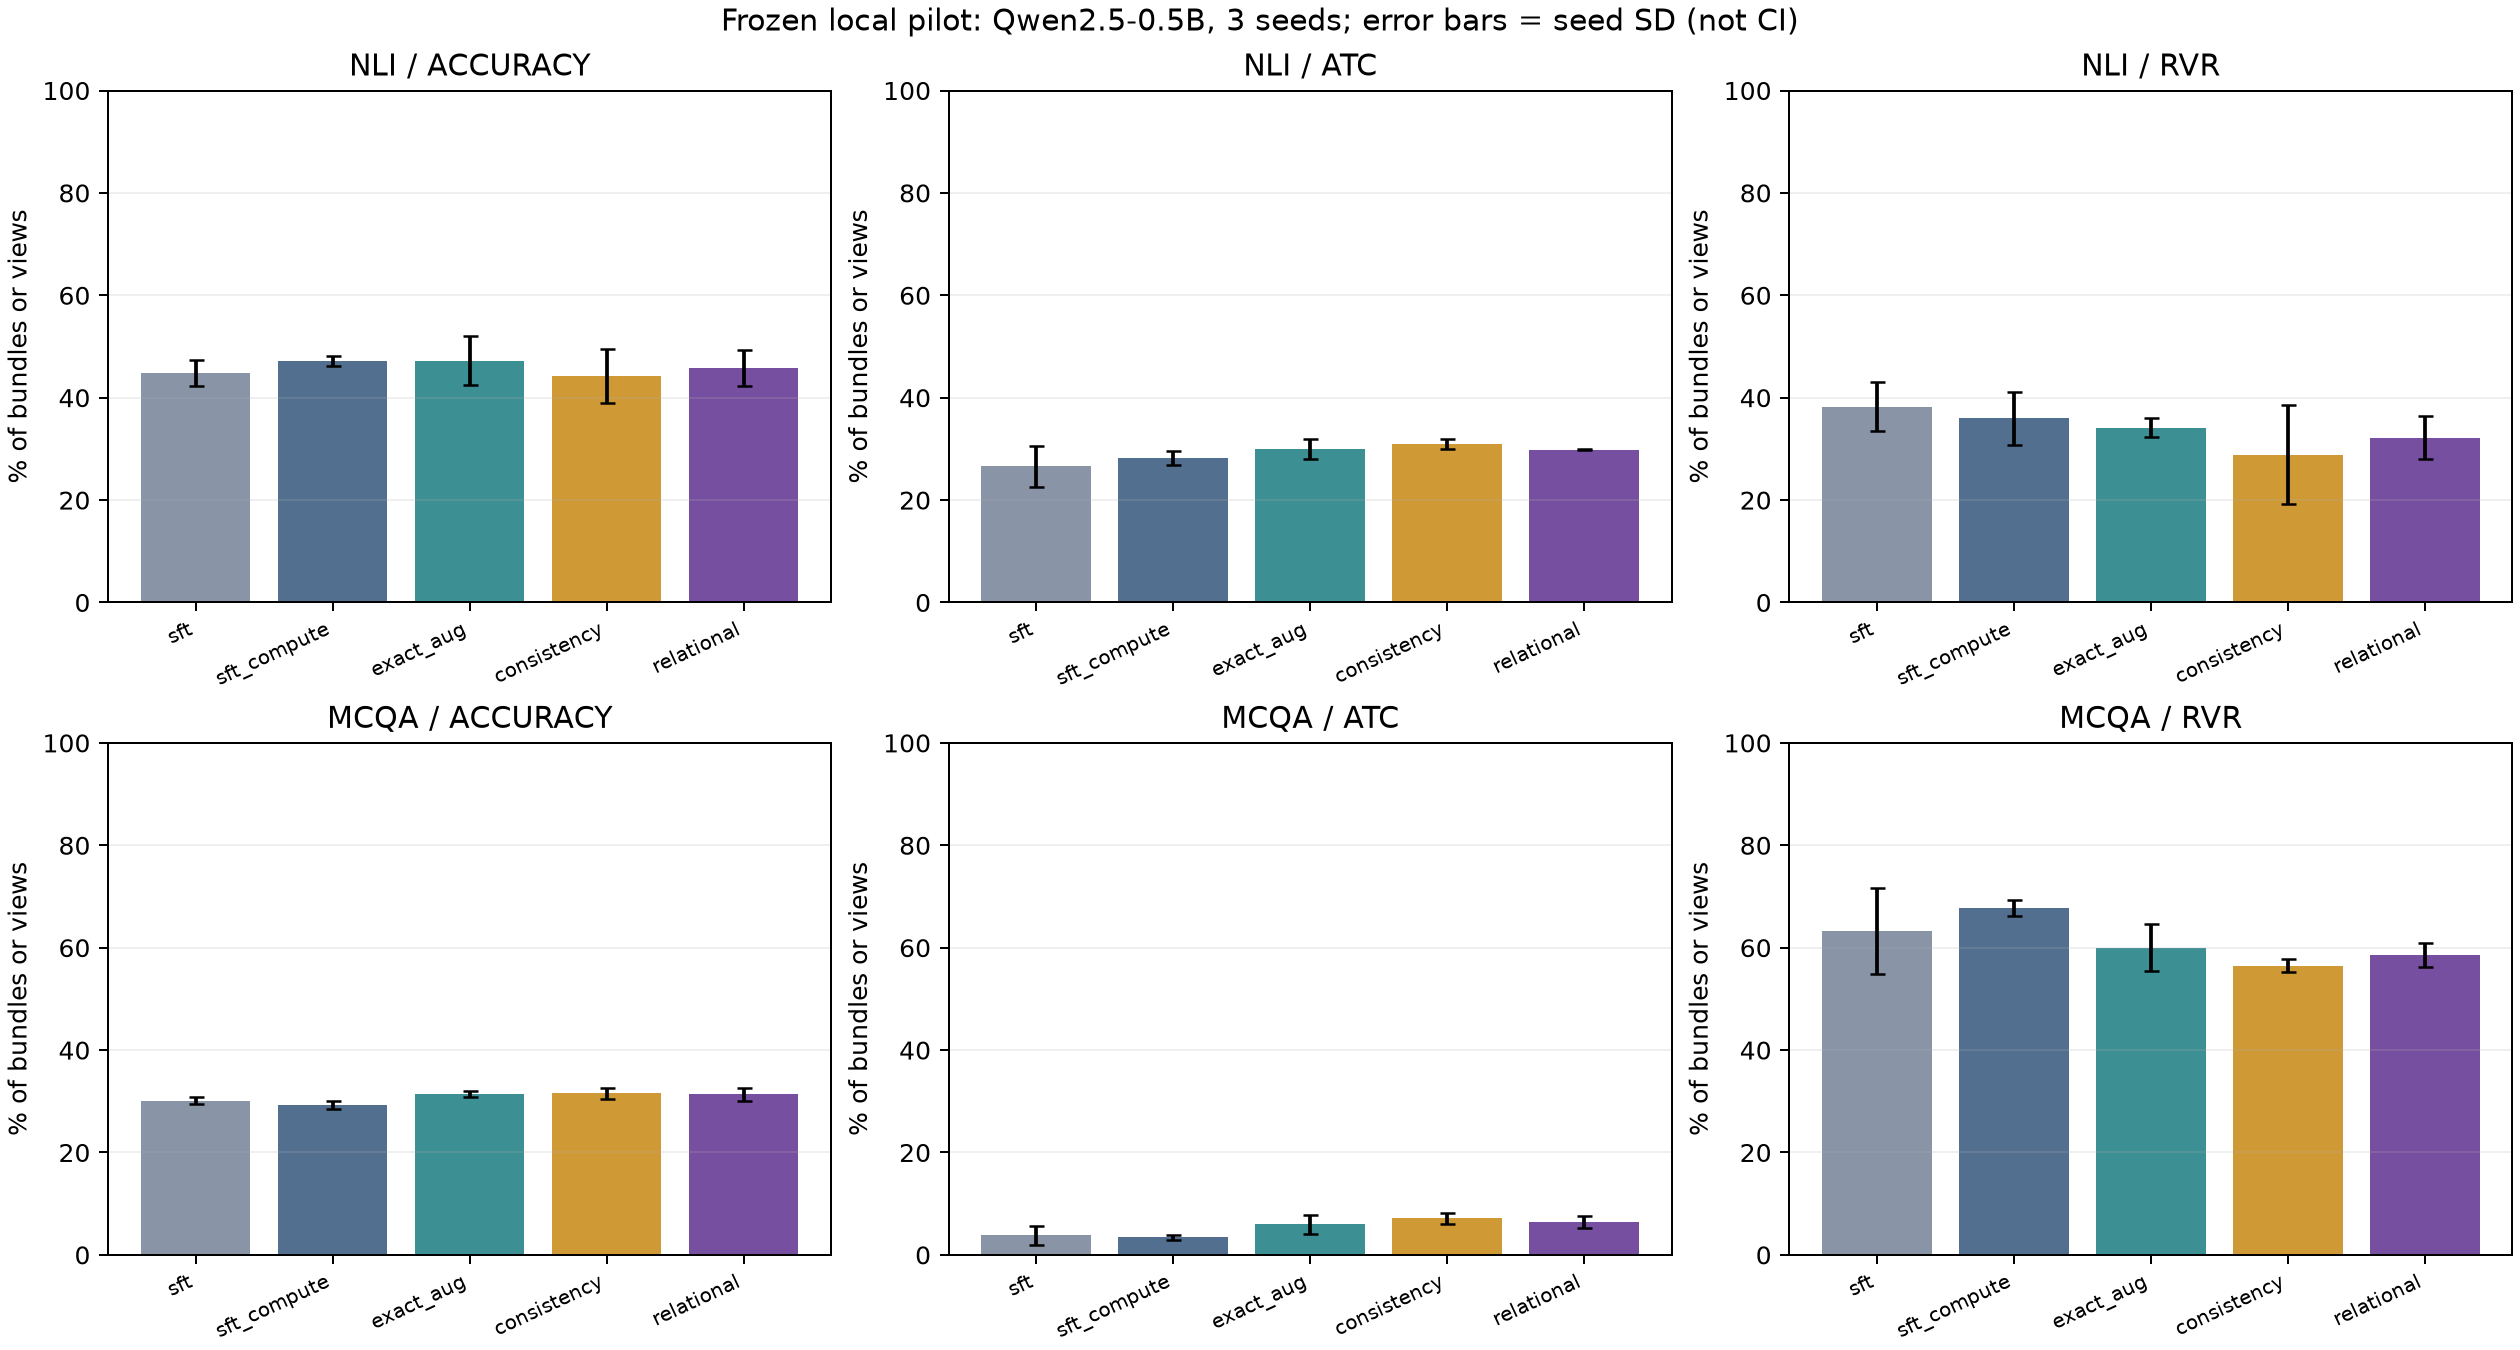

In [2]:
import pandas as pd
from IPython.display import display, Image, Markdown
rows = []
for task, arms in summary['aggregate']['ood'].items():
    for arm, metrics in arms.items():
        rows.append({'task': task, 'arm': arm, **{key: round(100 * metrics[key]['mean'], 3) for key in ('accuracy','atc','rvr','raw_first_token_invalid_rate')}})
display(pd.DataFrame(rows))
display(Image(filename=str(run / 'ood_comparison.png')))

In [3]:
rows = []
for task, pairs in summary['comparisons']['ood'].items():
    for pair, metrics in pairs.items():
        row = {'task': task, 'comparison': pair}
        for name, result in metrics.items():
            lo, hi = result['paired_bundle_95ci']
            row[name + ' delta [95% CI], pp'] = f"{100*result['mean']:+.2f} [{100*lo:+.2f}, {100*hi:+.2f}]"
        rows.append(row)
display(pd.DataFrame(rows))
print(json.dumps(summary['statistical_gates'], ensure_ascii=False, indent=2))

,task,comparison,"accuracy delta [95% CI], pp","atc delta [95% CI], pp","rvr delta [95% CI], pp"
0,nli,relational_minus_sft,"+0.91 [+0.16, +1.64]","+3.24 [+2.41, +4.15]","-6.01 [-7.28, -4.79]"
1,nli,relational_minus_sft_compute,"-1.46 [-2.45, -0.51]","+1.68 [+0.55, +2.82]","-3.76 [-5.37, -2.13]"
2,nli,relational_minus_exact_aug,"-1.48 [-2.16, -0.83]","-0.13 [-0.98, +0.73]","-1.97 [-3.03, -0.86]"
3,nli,relational_minus_consistency,"+1.57 [+0.81, +2.32]","-1.11 [-2.00, -0.23]","+3.30 [+2.18, +4.44]"
4,nli,consistency_minus_exact_aug,"-3.05 [-3.81, -2.30]","+0.98 [+0.06, +1.89]","-5.27 [-6.36, -4.10]"
5,mcqa,relational_minus_sft,"+1.26 [+0.68, +1.86]","+2.69 [+2.03, +3.30]","-4.62 [-5.62, -3.64]"
6,mcqa,relational_minus_sft_compute,"+2.08 [+1.38, +2.78]","+3.03 [+2.31, +3.74]","-9.19 [-10.24, -8.11]"
7,mcqa,relational_minus_exact_aug,"+0.00 [-0.37, +0.37]","+0.52 [+0.03, +0.99]","-1.36 [-2.09, -0.68]"
8,mcqa,relational_minus_consistency,"-0.22 [-0.55, +0.11]","-0.65 [-1.07, -0.23]","+2.10 [+1.46, +2.74]"
9,mcqa,consistency_minus_exact_aug,"+0.22 [-0.17, +0.60]","+1.17 [+0.67, +1.66]","-3.46 [-4.20, -2.76]"


{
  "nli": {
    "sft_compute": {
      "atc_positive": true,
      "accuracy_noninferior": false,
      "rvr_lower": true,
      "passed": false
    },
    "exact_aug": {
      "atc_positive": false,
      "accuracy_noninferior": false,
      "rvr_lower": true,
      "passed": false
    }
  },
  "mcqa": {
    "sft_compute": {
      "atc_positive": true,
      "accuracy_noninferior": true,
      "rvr_lower": true,
      "passed": true
    },
    "exact_aug": {
      "atc_positive": true,
      "accuracy_noninferior": true,
      "rvr_lower": true,
      "passed": true
    }
  }
}


### 继续研究的边界

ATC 要求同一源题的所有视图同时正确，RVR 仅衡量关系一致性。置信区间以三个固定训练种子为条件。只有新增允许集合项相对 `consistency` 的差值，才能衡量它的增量；全词表损失同时含格式监督，因此仍需进一步拆分。

原始代码位于 `experiments/local_scheme_validation/`。所有最终 adapter、概率、logits、margin、日志和独立验证均保留。后续改进需要新协议和新测试集；本轮测试数据不得成为调参依据。